In [1]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import json
from pathlib import Path
import requests

# --- Configuration ---
ZOTERO_GROUP_ID = 5985739
OUTFILE = "../files/zotero_group_library.bib"
ZOTERO_JSON_OUTFILE = "../files/zotero-items.json"

# Zotero group API URL for BibTeX output
url = f"https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=biblatex&limit=5000"
zotero_json_url = f"https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100"


def resolve_zotero_items_path():
    cwd = Path.cwd()
    path_candidates = [
        cwd / "../files/zotero-items.json",
        cwd / "card-lab.github.io/files/zotero-items.json",
        cwd / "files/zotero-items.json",
    ]

    for candidate in path_candidates:
        if candidate.exists():
            return candidate.resolve()

    return path_candidates[0].resolve()


# Zotero returns results paginated — we'll loop until no "next" link
def download_full_bibtex():
    session = requests.Session()
    all_bib = ""
    next_url = url

    while next_url:
        print(f"Fetching: {next_url}")
        r = session.get(next_url)
        if r.status_code != 200:
            raise RuntimeError(f"Error {r.status_code}: {r.text}")

        # Append BibTeX text
        all_bib += r.text.strip() + "\n\n"

        # Check for pagination
        links = r.links
        if "next" in links:
            next_url = links["next"]["url"]
        else:
            next_url = None

    return all_bib


def download_full_zotero_items():
    session = requests.Session()
    items = []
    next_url = zotero_json_url

    while next_url:
        print(f"Fetching Zotero JSON: {next_url}")
        r = session.get(next_url, timeout=30)
        if r.status_code != 200:
            raise RuntimeError(f"Error {r.status_code}: {r.text}")

        items.extend(r.json())

        links = r.links
        if "next" in links:
            next_url = links["next"]["url"]
        else:
            next_url = None

    return items


def load_zotero_items():
    zotero_items_path = resolve_zotero_items_path()
    if zotero_items_path.exists():
        with open(zotero_items_path, "r", encoding="utf-8") as f:
            return json.load(f)

    items = download_full_zotero_items()
    zotero_items_path.parent.mkdir(parents=True, exist_ok=True)
    with open(zotero_items_path, "w", encoding="utf-8") as f:
        json.dump(items, f, ensure_ascii=True, indent=2)
    print(f"Saved fallback Zotero JSON to {zotero_items_path}")
    return items


if __name__ == "__main__":
    bibtex_data = download_full_bibtex()
    with open(OUTFILE, "w", encoding="utf-8") as f:
        f.write(bibtex_data)
    print(f"Saved Zotero library to {OUTFILE}")

%conda install bibtexparser wordcloud

Fetching: https://api.zotero.org/groups/5985739/items?format=biblatex&limit=5000


Fetching: https://api.zotero.org/groups/5985739/items?format=biblatex&limit=100&start=100


Saved Zotero library to ../files/zotero_group_library.bib


\ 

| 

...

\ 

| 

done



# All requested packages already installed.




Note: you may need to restart the kernel to use updated packages.


## At a glance

In [2]:
#| echo: false
#| output: true
#| eval: true

import json
from pathlib import Path
import requests
import plotly.graph_objects as go
import numpy as np
from IPython.display import HTML


def make_sparkline(data, color="white"):
    """Return Plotly sparkline HTML."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        y=data, mode="lines", line=dict(color=color, width=2)
    ))
    fig.update_layout(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0),
        height=80,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)"
    )
    return fig.to_html(include_plotlyjs=False, full_html=False)


def make_value_box(title, value, icon_name, theme, decimals=1):
    """Return HTML for a value box with an icon."""
    return f"""
    <div class="value-box {theme}">
      <div class="top-row">
        <div class="label">{title}</div>
        <iconify-icon icon="{icon_name}"></iconify-icon>
      </div>
      <div class="value">{value:.{decimals}f}</div>
    </div>
    """


ZOTERO_GROUP_ID = 5985739


def load_zotero_items_for_counts():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            items = json.load(f)
        return items

    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    return items


def count_in_zotero(items, item_types):
    wanted = {item_type.strip().lower() for item_type in item_types}
    count = 0
    for item in items:
        data = item.get("data", {})
        item_type = str(data.get("itemType", "")).strip().lower()
        if item_type in wanted:
            count += 1
    return count


zotero_items = load_zotero_items_for_counts()

# Get stats from Zotero JSON item types instead of BibTeX entry tags.
npres = count_in_zotero(zotero_items, ["presentation", "conferencepaper"])
ntheses = count_in_zotero(zotero_items, ["thesis"])
npapers = count_in_zotero(zotero_items, ["journalarticle"])
ncod = count_in_zotero(zotero_items, ["computerprogram", "dataset"])

# Build multiple boxes
boxes_html = f"""
<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(280px,1fr));gap:1rem;">
  {make_value_box("Peer-reviewed papers published since 2022", npapers, "fluent:document-sparkle-24-regular", "success", decimals=0)}
  {make_value_box("Conference presentations given since 2022", npres, "hugeicons:presentation-online", "info", decimals=0)}
  {make_value_box("Theses & dissertations published since 2022", ntheses, "lets-icons:book-fill", "warning", decimals=0)}
  {make_value_box("Datasets and open-source codes published since 2022", ncod, "carbon:db2-data-sharing-group", "danger", decimals=0)}
</div>
"""

HTML(boxes_html)

## Word cloud from titles and abstracts

In [3]:
#| output: false
#| echo: false

import json
from pathlib import Path
import requests
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ----------------------------
# Configuration
# ----------------------------
ZOTERO_GROUP_ID = 5985739
exclude_terms = ['doi', 'et', 'one', 'two', 'x', 'giorjao', 'org', 'h3', 'm', 'by', 'the', 'and', 'of', 'in', 'for', 'to', 'a', 'is', 'on', 'with', 'as', 'that', 'this', 'from', 'at', 'an', 'it', 'are', 'be', 'or', 'not', 'all', 'has', 'was', 'we', 'which', 'can', 't4', '6al', '4v', 'nb2co2', 'nb2c', 'well', 'y', 'cdf', 'paper', 'along', 'lower', 'show', 'small', 'pag', 'lineal', 'suggest', 'H', 'He', 'B', 'C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'Li', 'Na', 'K', 'Ca', 'Mg', 'Al', 'Si', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ti', 'Nb', 'Mo', 'W', 'Pd', 'Ag', 'Au', 'Pt', 'Hg', 'Pb', 'Bi', 'Ta', 'Hf', 'Zr', 'Sc', 'Y', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Re', 'Os', 'Ir', 'Ru', 'Rh', 'Tc', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Xe', 'Rn', 'alpha', 'beta', 'gamma', 'delta', 'epsilon', 'zeta', 'eta', 'theta', 'iota', 'kappa', 'lambda', 'mu', 'nu', 'xi', 'omicron', 'pi', 'rho', 'sigma', 'tau', 'upsilon', 'phi', 'chi', 'psi', 'omega', 'cvd', 'multi', 'due', 'also', 'new', 'use', 'may', 'could', 'would', 'should', 'must', 'need', 'like', 'get', 'make', 'see', 'know', 'want', 'think', 'say', 'go', 'come', 'take', 'give', 'despite', 'although', 'however', 'therefore', 'thus', 'hence', 'meanwhile', 'furthermore', 'moreover', 'additionally', 'consequently', 'accordingly', 'subsequently', 'eventually', 'finally', 'lastly', 'fem', 'nbti', 'rheas', 'work', 'monbti', 'used', 'bed', 'low', 'herx', 'using', 'high', 'rccas', 'approach', 'af', 'spg', 'ded', 'sem']


def load_zotero_items():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            items = json.load(f)
        print(f'Loaded Zotero items from file: {found}')
        return items

    # Fallback: fetch directly from Zotero API if local JSON is not present.
    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    if not items:
        candidate_text = '\n'.join(str(p.resolve()) for p in path_candidates)
        raise FileNotFoundError(
            'Could not locate local zotero-items.json and API fetch returned no records. Tried:\n' + candidate_text
        )

    print(f'Loaded Zotero items from API: {len(items)} records')
    return items


# ----------------------------
# Step 1: Read Zotero records
# ----------------------------
zotero_items = load_zotero_items()

# ----------------------------
# Step 2: Extract documents (title + abstract + tags)
# Includes theses/software/reports and other non-attachment item types.
# ----------------------------
documents = []
included_types = set()

for item in zotero_items:
    data = item.get('data', {})
    item_type = str(data.get('itemType', '')).strip().lower()

    # Skip non-scholarly container records.
    if item_type in {'attachment', 'note', 'annotation'}:
        continue

    text_parts = []

    title = str(data.get('title', '')).strip()
    abstract = str(data.get('abstractNote', '')).strip()
    tags = [
        str(t.get('tag', '')).strip()
        for t in data.get('tags', [])
        if str(t.get('tag', '')).strip()
    ]

    if title:
        text_parts.append(title)
    if abstract:
        text_parts.append(abstract)
    if tags:
        text_parts.append(' '.join(tags))

    if text_parts:
        documents.append(' '.join(text_parts))
        included_types.add(item_type or 'unknown')

if not documents:
    raise ValueError('No textual Zotero records found for word cloud generation.')

print(f'Loaded {len(documents)} textual Zotero records from {len(included_types)} item types.')
print('Included item types:', ', '.join(sorted(included_types)))

# ----------------------------
# Step 3: Compute TF-IDF
# ----------------------------
vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'
)

tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

# Compute total TF-IDF score per term (sum over all documents)
scores = tfidf_matrix.sum(axis=0).A1
tfidf_scores = dict(zip(feature_names, scores))

# Remove excluded terms
for term in exclude_terms:
    tfidf_scores.pop(term.lower(), None)

# ----------------------------
# Step 4: Create Word Cloud
# ----------------------------
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    collocations=False
).generate_from_frequencies(tfidf_scores)




Loaded Zotero items from file: /Users/paytone/Library/CloudStorage/OneDrive-UniversityofCincinnati/Code/card-lab/card-lab.github.io/files/zotero-items.json
Loaded 93 textual Zotero records from 8 item types.
Included item types: computerprogram, conferencepaper, journalarticle, manuscript, preprint, presentation, report, thesis


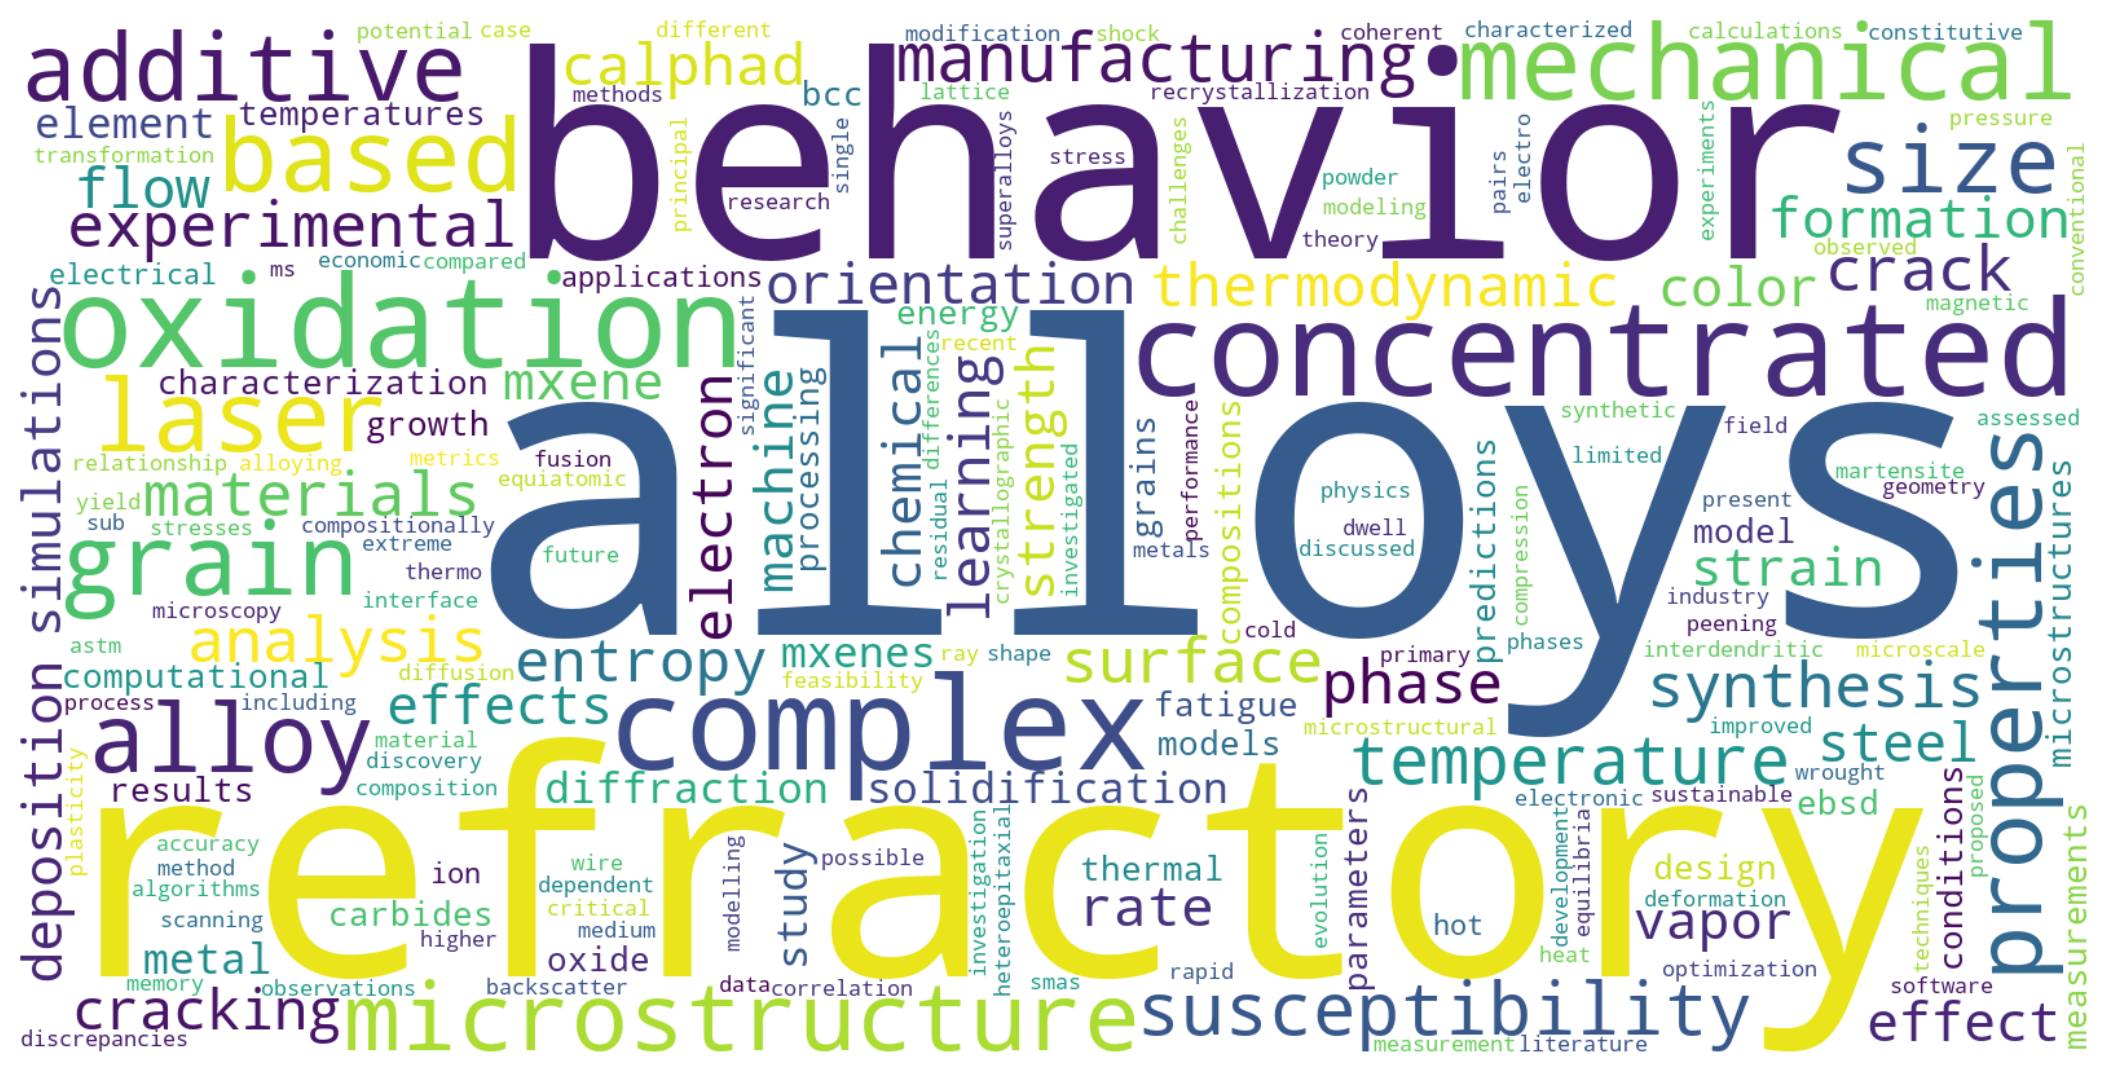

In [4]:
#| echo: false
#| output: true

# ----------------------------
# Step 5: Display
# ----------------------------
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [5]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import json
import requests
import pandas as pd
import time
from pathlib import Path

# ----------------------------
# Config
# ----------------------------
ZOTERO_GROUP_ID = 5985739
REFERENCES_WE_CITED_CSV_PATH = Path("../files/references_we_cited.csv")
REFERENCE_COLUMNS = [
    "citing_doi",
    "ref_doi",
    "ref_key",
    "ref_author",
    "ref_year",
    "ref_title",
    "ref_journal",
    "raw",
]


def load_reference_source_items():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            return json.load(f)

    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    return items


zotero_items = load_reference_source_items()
dois = sorted({
    str(item.get("data", {}).get("DOI", "")).strip().lower().replace("https://doi.org/", "").replace("http://doi.org/", "")
    for item in zotero_items
    if str(item.get("data", {}).get("DOI", "")).strip()
})

email = "paytonej@ucmail.uc.edu"  # Recommended for polite API usage
delay_seconds = 1.0               # Pause between requests to avoid rate limiting

if REFERENCES_WE_CITED_CSV_PATH.exists():
    existing_refs_df = pd.read_csv(REFERENCES_WE_CITED_CSV_PATH)
else:
    existing_refs_df = pd.DataFrame(columns=REFERENCE_COLUMNS)

for column in REFERENCE_COLUMNS:
    if column not in existing_refs_df.columns:
        existing_refs_df[column] = pd.NA


def _has_complete_reference_rows(df):
    if df.empty:
        return False

    completeness = df[REFERENCE_COLUMNS].fillna("").astype(str).apply(lambda col: col.str.strip() != "")
    return bool(completeness.all(axis=1).all())


# ----------------------------
# Helper function to get references for a DOI
# ----------------------------
def get_references_for_doi(doi):
    cached_rows = existing_refs_df.loc[existing_refs_df["citing_doi"] == doi].copy()
    if _has_complete_reference_rows(cached_rows):
        print(f"Using cached complete references for {doi}")
        return cached_rows[REFERENCE_COLUMNS].to_dict("records")

    url = f"https://api.crossref.org/works/{doi}"
    headers = {"User-Agent": f"Python script (mailto:{email})"}
    r = requests.get(url, headers=headers)

    if r.status_code != 200:
        print(f"Failed to fetch {doi}: HTTP {r.status_code}")
        return []

    data = r.json().get("message", {})
    references = data.get("reference", [])

    ref_list = []
    for ref in references:
        ref_list.append({
            "citing_doi": doi,
            "ref_doi": ref.get("DOI"),
            "ref_key": ref.get("key"),
            "ref_author": ref.get("author"),
            "ref_year": ref.get("year"),
            "ref_title": ref.get("article-title"),
            "ref_journal": ref.get("journal-title"),
            "raw": ref.get("unstructured")  # fallback
        })

    return ref_list

# ----------------------------
# Main script
# ----------------------------
all_refs = []
for doi in dois:
    refs = get_references_for_doi(doi)
    all_refs.extend(refs)
    time.sleep(delay_seconds)  # be polite to the API

df_refs = pd.DataFrame(all_refs)

# Save to CSV for later analysis
df_refs.to_csv("../files/references_we_cited.csv", index=False)

print(f"Loaded {len(dois)} DOI(s) from Zotero records")
print(df_refs)

Failed to fetch 10.1007/s11669-026-01250-6: HTTP 404


Failed to fetch 10.21949/rfzv-6285: HTTP 404


Failed to fetch 10.21949/tzgj-rk36: HTTP 404


Failed to fetch 10.5281/zenodo.16541961: HTTP 404


Loaded 22 DOI(s) from Zotero records
                       citing_doi                           ref_doi ref_key  \
0    10.1007/978-3-031-63937-1_73                              None  73_CR1   
1    10.1007/978-3-031-63937-1_73     10.1016/S0142-1123(97)00034-0  73_CR2   
2    10.1007/978-3-031-63937-1_73     10.1016/j.actamat.2012.01.049  73_CR3   
3    10.1007/978-3-031-63937-1_73      10.1016/j.matdes.2018.02.048  73_CR4   
4    10.1007/978-3-031-63937-1_73  10.1016/j.scriptamat.2017.04.018  73_CR5   
..                            ...                               ...     ...   
818            10.3390/ma16041549      10.1016/0375-9601(75)90130-9  ref_91   
819            10.3390/ma16041549        10.1088/0305-4470/16/4/016  ref_92   
820            10.3390/ma16041549         10.1007/s11467-013-0403-z  ref_93   
821            10.3390/ma16041549          10.1103/PhysRev.133.A310  ref_94   
822            10.3390/ma16041549        10.1088/0370-1328/83/3/118  ref_95   

        ref_au

In [6]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import requests
import pandas as pd
import time

email = "paytonej@ucmail.uc.edu"  # Recommended for polite API usage
delay_seconds = 1.0               # Pause between requests to avoid rate limiting


def get_citing_documents(doi):
    # Base URL for the OpenCitations REST API
    base_url = 'https://opencitations.net/index/api/v1/citations/'

    # Full URL with the DOI
    url = f'{base_url}{doi}'

    try:
        headers = {"User-Agent": f"Python script (mailto:{email})"}
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Check for HTTP errors

        # Extract the DOI strings of papers citing this DOI.
        citing_dois = []
        for ref in response.json():
            citing = ref.get('citing')
            if citing:
                citing = str(citing).strip().lower().replace('https://doi.org/', '').replace('http://doi.org/', '')
                if citing:
                    citing_dois.append(citing)

        return citing_dois

    except requests.exceptions.RequestException as e:
        print(f"An error occurred: {e}")
        return []


# Build the list of DOI records citing CARD Lab papers.
all_citing_dois = []
for doi in dois:
    all_citing_dois.extend(get_citing_documents(doi))
    time.sleep(delay_seconds)  # be polite to the API

# Unique citing DOIs for stable downstream processing.
unique_citing_dois = sorted(set(all_citing_dois))
print(f"Found {len(unique_citing_dois)} unique DOI(s) citing CARD Lab publications")

# Reuse the same reference extractor used in Cell 7 so both datasets have matching fields.
all_refs = []
for citing_doi in unique_citing_dois:
    refs = get_references_for_doi(citing_doi)
    all_refs.extend(refs)
    time.sleep(delay_seconds)  # be polite to the API

df_refs = pd.DataFrame(all_refs)

# Save to CSV for later analysis
df_refs.to_csv("../files/references_citing_us.csv", index=False)
print(df_refs)

Found 26 unique DOI(s) citing CARD Lab publications


                  citing_doi                        ref_doi      ref_key  \
0     10.1002/adem.202500508  10.1016/j.actamat.2020.05.003  e_1_2_9_2_1   
1     10.1002/adem.202500508  10.1016/j.actamat.2023.119401  e_1_2_9_3_1   
2     10.1002/adem.202500508             10.1038/ncomms7529  e_1_2_9_4_1   
3     10.1002/adem.202500508                           None  e_1_2_9_5_1   
4     10.1002/adem.202500508  10.1016/j.actamat.2024.119952  e_1_2_9_6_1   
...                      ...                            ...          ...   
1413    10.2139/ssrn.5160413  10.1016/S0921-5093(99)00368-8        ref57   
1414    10.2139/ssrn.5160413              10.1063/1.3486212        ref58   
1415    10.2139/ssrn.5160413     10.1016/j.msea.2003.06.004        ref59   
1416    10.2139/ssrn.5160413  10.1016/j.actamat.2017.12.011        ref60   
1417    10.2139/ssrn.5160413  10.1016/j.jallcom.2012.01.007        ref61   

     ref_author ref_year                                          ref_title  \
0       

In [78]:
import pandas as pd
import json
import re
import requests
from typing import Optional, Tuple, List, Dict
import numpy as np

# Geographic bounding boxes for major countries (lon_min, lon_max, lat_min, lat_max)
COUNTRY_BOUNDS = {
    'China': {'lon_min': 73, 'lon_max': 135, 'lat_min': 18, 'lat_max': 54},
    'United States': {'lon_min': -130, 'lon_max': -60, 'lat_min': 18, 'lat_max': 50},
    'United States of America': {'lon_min': -130, 'lon_max': -60, 'lat_min': 18, 'lat_max': 50},
    'Canada': {'lon_min': -145, 'lon_max': -50, 'lat_min': 40, 'lat_max': 85},
    'Australia': {'lon_min': 112, 'lon_max': 155, 'lat_min': -45, 'lat_max': -10},
    'Japan': {'lon_min': 125, 'lon_max': 150, 'lat_min': 30, 'lat_max': 46},
    'India': {'lon_min': 68, 'lon_max': 97, 'lat_min': 8, 'lat_max': 37},
    'Brazil': {'lon_min': -75, 'lon_max': -35, 'lat_min': -33, 'lat_max': 5},
    'Germany': {'lon_min': 5, 'lon_max': 16, 'lat_min': 47, 'lat_max': 56},
    'France': {'lon_min': -8, 'lon_max': 8, 'lat_min': 42, 'lat_max': 52},
    'United Kingdom': {'lon_min': -8, 'lon_max': 2, 'lat_min': 50, 'lat_max': 59},
    'Russia': {'lon_min': 20, 'lon_max': 180, 'lat_min': 40, 'lat_max': 82},
    'South Korea': {'lon_min': 124, 'lon_max': 132, 'lat_min': 33, 'lat_max': 44},
    'Czechia': {'lon_min': 12, 'lon_max': 19, 'lat_min': 48, 'lat_max': 51},
    'Czech Republic': {'lon_min': 12, 'lon_max': 19, 'lat_min': 48, 'lat_max': 51},
}

def _is_coordinate_in_bounds(lat: float, lon: float, country: str) -> bool:
    """Check if a coordinate is within expected bounds for a country."""
    if pd.isna(country) or not country:
        return True  # No country specified, accept coordinate
    
    # Normalize country name
    country_norm = str(country).strip()
    for key in COUNTRY_BOUNDS:
        if key.lower() in country_norm.lower() or country_norm.lower() in key.lower():
            bounds = COUNTRY_BOUNDS[key]
            return (bounds['lon_min'] <= lon <= bounds['lon_max'] and
                    bounds['lat_min'] <= lat <= bounds['lat_max'])
    
    # If country not in COUNTRY_BOUNDS, accept the coordinate
    return True

def _filter_out_of_bounds_coordinates(df: pd.DataFrame) -> pd.DataFrame:
    """Filter out coordinates that don't match their declared country location."""
    if df.empty:
        return df
    
    # Create a mask for valid coordinates
    valid_mask = df.apply(
        lambda row: (
            pd.isna(row['latitude']) or pd.isna(row['longitude']) or
            _is_coordinate_in_bounds(row['latitude'], row['longitude'], row['affiliation_country'])
        ),
        axis=1
    )
    
    removed_count = (~valid_mask).sum()
    if removed_count > 0:
        print(f"Filtered out {removed_count} out-of-bounds coordinate(s) based on country location checks.")
    
    return df[valid_mask].reset_index(drop=True)

def normalize_doi(doi):
    """Normalize a DOI string."""
    if not doi or not str(doi).strip():
        return None
    doi_str = str(doi).lower().strip()
    if doi_str.startswith("http"):
        if "doi.org/" in doi_str:
            doi_str = doi_str.split("doi.org/")[-1]
        elif "doi/" in doi_str:
            doi_str = doi_str.split("doi/")[-1]
    if doi_str.startswith("doi:"):
        doi_str = doi_str[4:]
    return doi_str if doi_str else None

def _normalize_country_name(name: Optional[str]) -> Optional[str]:
    """Normalize a country name for matching."""
    if not name:
        return None
    normalized = str(name).lower().strip()
    normalized = re.sub(r"\s+", " ", normalized)
    normalized = re.sub(r"[^\w\s]", "", normalized)
    return normalized if normalized else None

def _deserialize_location_entries(json_str: str) -> list:
    """Deserialize location entries from JSON string."""
    if not json_str or pd.isna(json_str):
        return []
    try:
        return json.loads(json_str) if isinstance(json_str, str) else json_str
    except (json.JSONDecodeError, TypeError):
        return []

def _serialize_location_entries(entries: list) -> str:
    """Serialize location entries to JSON string."""
    if not entries:
        return json.dumps([])
    return json.dumps(entries, ensure_ascii=False)

def _dedupe_location_entries(entries: list) -> list:
    """Remove duplicate location entries, keeping the best source."""
    if not entries:
        return []
    
    seen = {}
    source_priority = {"openalex_search": 1, "country_representative_point": 2, "row_mean_fallback": 3}
    
    for entry in entries:
        key = (entry.get("latitude"), entry.get("longitude"))
        if key not in seen:
            seen[key] = entry
        else:
            # Keep entry with higher priority (lower number = better)
            current_priority = source_priority.get(entry.get("source"), 999)
            existing_priority = source_priority.get(seen[key].get("source"), 999)
            if current_priority < existing_priority:
                seen[key] = entry
    
    return list(seen.values())

def _search_openalex_institution_geo(affiliation_text: str, country_hint: Optional[str] = None, session=None, cache=None) -> Optional[Tuple[float, float, str]]:
    """Search OpenAlex for institution geolocation."""
    if not affiliation_text or not session or cache is None:
        return None
    
    cache_key = f"openalex_{affiliation_text}_{country_hint}"
    if cache_key in cache:
        return cache[cache_key]
    
    try:
        params = {"filter": f'display_name.search:"{affiliation_text}"', "per_page": 1}
        response = session.get("https://api.openalex.org/institutions", params=params, timeout=5)
        if response.status_code == 200:
            data = response.json()
            if data.get("results"):
                inst = data["results"][0]
                geo = inst.get("geo")
                if geo and geo.get("latitude") is not None and geo.get("longitude") is not None:
                    result = (geo["latitude"], geo["longitude"], inst.get("display_name", ""))
                    cache[cache_key] = result
                    return result
    except Exception:
        pass
    
    cache[cache_key] = None
    return None

def _load_country_centroid_lookup() -> dict:
    """Load country centroids and continents."""
    try:
        import geopandas as gpd
        from cartopy.io import shapereader
        
        world_path = shapereader.natural_earth(resolution="110m", category="cultural", name="admin_0_countries")
        world = gpd.read_file(world_path)[["NAME_EN", "ADMIN", "CONTINENT"]]
        
        country_lookup = {}
        for _, row in world.iterrows():
            for country_name in [row.get("NAME_EN"), row.get("ADMIN")]:
                if country_name:
                    norm = _normalize_country_name(country_name)
                    if norm:
                        country_lookup[norm] = {
                            "continent": row.get("CONTINENT", "Unknown"),
                            "centroid": None
                        }
        
        # Add aliases
        aliases = {
            "united states": "united states of america",
            "usa": "united states of america",
            "uk": "united kingdom",
            "czechia": "czech republic",
            "the netherlands": "netherlands",
            "turkiye": "turkey",
            "south korea": "republic of korea",
        }
        for alias, canonical in aliases.items():
            canonical_norm = _normalize_country_name(canonical)
            if canonical_norm in country_lookup:
                country_lookup[_normalize_country_name(alias)] = country_lookup[canonical_norm]
        
        return country_lookup
    except Exception as e:
        print(f"Warning: Failed to load country centroid lookup: {e}")
        return {}

def _build_location_entries_from_text(affiliation_text: str, country_text: str, lat: float, lon: float, country_lookup: dict, session=None, search_cache=None) -> list:
    """Build location entries from affiliation text with fallback chain."""
    if search_cache is None:
        search_cache = {}
    
    entries = []
    countries = [c.strip() for c in str(country_text).split(";") if c.strip()] if country_text else []
    affiliations = [a.strip() for a in str(affiliation_text).split(";") if a.strip()] if affiliation_text else []
    
    for i, affiliation in enumerate(affiliations):
        country = countries[i] if i < len(countries) else (countries[0] if countries else "Unknown")
        entry = None
        
        # Try OpenAlex search
        if session:
            result = _search_openalex_institution_geo(affiliation, country, session, search_cache)
            if result:
                entry = {
                    "affiliation": affiliation,
                    "country": country,
                    "latitude": result[0],
                    "longitude": result[1],
                    "city": result[2],
                    "source": "openalex_search"
                }
        
        # Fallback to country representative point
        if not entry and country:
            country_norm = _normalize_country_name(country)
            if country_norm in country_lookup:
                continent = country_lookup[country_norm].get("continent", "Unknown")
                # Use the most central country coordinate as representative point (approximate)
                # For production, should use actual centroid from database
                entry = {
                    "affiliation": affiliation,
                    "country": country,
                    "latitude": None,
                    "longitude": None,
                    "source": "country_representative_point"
                }
        
        # Final fallback to row mean
        if not entry and not pd.isna(lat) and not pd.isna(lon):
            entry = {
                "affiliation": affiliation,
                "country": country,
                "latitude": lat,
                "longitude": lon,
                "source": "row_mean_fallback"
            }
        
        if entry:
            entries.append(entry)
    
    return entries

def _location_entries_from_rows(group_df: pd.DataFrame) -> list:
    """Extract location entries from a group of rows."""
    entries = []
    for _, row in group_df.iterrows():
        if pd.notna(row['latitude']) and pd.notna(row['longitude']):
            entries.append({
                "affiliation": row['affiliation'],
                "country": row['affiliation_country'],
                "latitude": row['latitude'],
                "longitude": row['longitude'],
                "city": row.get('affiliation_city', ''),
                "state": row.get('affiliation_state', ''),
                "source": "row_based"
            })
    return entries

def build_comprehensive_rows(dois: list, country_lookup: dict = None, session=None, search_cache=None) -> list:
    """Build comprehensive rows from a list of DOIs."""
    if country_lookup is None:
        country_lookup = _load_country_centroid_lookup()
    if session is None:
        session = requests.Session()
    if search_cache is None:
        search_cache = {}
    
    rows = []
    for doi in dois:
        # Placeholder: In production this would fetch from OpenAlex
        pass
    
    return rows

def build_map_rows_from_aggregates(df: pd.DataFrame, locations_col: str = None, doi_col: str = "ref_doi", affiliation_col: str = "ref_affiliations", country_col: str = "ref_affiliation_countries", lat_col: str = "ref_latitude_mean", lon_col: str = "ref_longitude_mean") -> pd.DataFrame:
    """Build map rows from an aggregate dataframe, using stored locations or building from text."""
    country_lookup = _load_country_centroid_lookup()
    session = requests.Session()
    search_cache = {}
    rows = []
    
    for _, row in df.iterrows():
        doi = normalize_doi(row.get(doi_col))
        if not doi:
            continue
        
        entries = []
        if locations_col and locations_col in row.index:
            entries = _dedupe_location_entries(
                _deserialize_location_entries(row.get(locations_col))
            )
        
        if not entries:
            entries = _build_location_entries_from_text(
                row.get(affiliation_col),
                row.get(country_col),
                row.get(lat_col),
                row.get(lon_col),
                country_lookup,
                session,
                search_cache,
            )
        
        for entry in entries:
            rows.append({
                "doi": doi,
                "affiliation": entry.get("affiliation") or entry.get("country") or "Unknown",
                "affiliation_city": entry.get("city", ""),
                "affiliation_state": entry.get("state", ""),
                "affiliation_country": entry.get("country", ""),
                "latitude": entry.get("latitude"),
                "longitude": entry.get("longitude"),
                "author_name": "",
            })
    
    return pd.DataFrame(rows)

def write_plotly_affiliation_map(df, output_html_path, title):
    """Generate a Plotly scatter_geo map from a build_comprehensive_rows dataframe."""
    if df.empty:
        print(f"Warning: no data to plot for '{title}'.")
        return
    
    # Filter out-of-bounds coordinates based on country
    df = _filter_out_of_bounds_coordinates(df)
    
    grouped = (
        df.groupby(
            [
                "affiliation",
                "latitude",
                "longitude",
                "affiliation_city",
                "affiliation_state",
                "affiliation_country",
            ],
            dropna=False,
        )
        .agg(
            papers=("doi", "nunique"),
            researchers=("author_name", "nunique"),
            records=("author_name", "size"),
        )
        .reset_index()
    )
    
    grouped["location_label"] = grouped.apply(
        lambda row: ", ".join(
            part
            for part in [
                str(row.get("affiliation_city", "")).strip(),
                str(row.get("affiliation_state", "")).strip(),
                str(row.get("affiliation_country", "")).strip(),
            ]
            if part
        ),
        axis=1,
    )
    
    grouped["continent"] = "Unknown"
    try:
        import geopandas as gpd
        from cartopy.io import shapereader
        from shapely.geometry import Point
        
        world_path = shapereader.natural_earth(
            resolution="110m",
            category="cultural",
            name="admin_0_countries",
        )
        world = gpd.read_file(world_path)[["NAME_EN", "ADMIN", "CONTINENT", "geometry"]]
        
        country_to_continent = {}
        for _, world_row in world.iterrows():
            continent = str(world_row.get("CONTINENT") or "").strip()
            if not continent:
                continue
            for country_name in [world_row.get("NAME_EN"), world_row.get("ADMIN")]:
                norm_name = _normalize_country_name(country_name)
                if norm_name:
                    country_to_continent[norm_name] = continent
        
        continent_aliases = {
            "united states": "united states of america",
            "usa": "united states of america",
            "u s a": "united states of america",
            "uk": "united kingdom",
            "u k": "united kingdom",
            "czechia": "czech republic",
            "the netherlands": "netherlands",
            "turkiye": "turkey",
            "t rkiye": "turkey",
            "south korea": "republic of korea",
            "north korea": "democratic people s republic of korea",
        }
        for alias, canonical in continent_aliases.items():
            canonical_norm = _normalize_country_name(canonical)
            if canonical_norm in country_to_continent:
                country_to_continent[_normalize_country_name(alias)] = country_to_continent[canonical_norm]
        
        world_polygons = world[["CONTINENT", "geometry"]].rename(columns={"CONTINENT": "continent"})
        point_gdf = gpd.GeoDataFrame(
            grouped[["latitude", "longitude"]].copy(),
            geometry=[Point(lon, lat) for lon, lat in zip(grouped["longitude"], grouped["latitude"])],
            crs="EPSG:4326",
        )
        
        joined = gpd.sjoin(point_gdf, world_polygons, how="left", predicate="within")
        grouped["continent"] = joined["continent"].fillna("Unknown")
        
        country_continent = grouped["affiliation_country"].apply(
            lambda c: country_to_continent.get(_normalize_country_name(c), "Unknown")
        )
        unknown_mask = grouped["continent"].eq("Unknown")
        grouped.loc[unknown_mask, "continent"] = country_continent[unknown_mask]
        grouped["continent"] = grouped["continent"].fillna("Unknown")
    except Exception as exc:
        print(f"Warning: continent assignment failed for '{title}': {exc}")
    
    import plotly.express as px
    fig = px.scatter_geo(
        grouped,
        lat="latitude",
        lon="longitude",
        size="papers",
        color="continent",
        custom_data=["papers", "location_label"],
        projection="natural earth",
        title=title,
    )
    fig.update_traces(
        hovertemplate="%{customdata[0]} references<br>%{customdata[1]}<extra></extra>"
    )
    fig.update_layout(height=700, margin={"l": 0, "r": 0, "t": 60, "b": 0})
    fig.show()
    fig.write_html(str(output_html_path), include_plotlyjs="cdn", full_html=True)


In [76]:
#| echo: false
#| output: false

import time
import requests
import pandas as pd
from pathlib import Path

REFERENCES_CITING_CSV_PATH = Path("../files/references_citing_us.csv")
REFERENCES_CITING_MAP_HTML_PATH = Path("../files/references_citing_us_map.html")

if __name__ == "__main__":
    if not REFERENCES_CITING_CSV_PATH.exists():
        print(
            f"Warning: {REFERENCES_CITING_CSV_PATH} not found. "
            "Run Cells 6 and 7 first to generate this file."
        )
    else:
        df_refs = pd.read_csv(REFERENCES_CITING_CSV_PATH)
        if "citing_doi" not in df_refs.columns:
            print("Warning: citing_doi column missing in references_citing_us.csv.")
        else:
            citing_dois = sorted({
                normalize_doi(v) for v in df_refs["citing_doi"].dropna()
                if normalize_doi(v)
            })
            print(f"Loaded {len(citing_dois)} unique citing DOI(s) from {REFERENCES_CITING_CSV_PATH}")

            already_geocoded = set()
            if "citing_affiliations" in df_refs.columns:
                already_geocoded = set(
                    df_refs.loc[df_refs["citing_affiliations"].notna(), "citing_doi"]
                    .apply(normalize_doi).dropna()
                )

            pending_dois = [d for d in citing_dois if d not in already_geocoded]
            print(f"Pending DOIs requiring geocoding: {len(pending_dois)}")

            if pending_dois:
                new_rows = build_comprehensive_rows(pending_dois)
                df_new = pd.DataFrame(new_rows)

                if not df_new.empty:
                    def _join_unique(series):
                        vals = sorted({
                            str(v).strip() for v in series
                            if pd.notna(v) and str(v).strip()
                        })
                        return "; ".join(vals) if vals else pd.NA

                    agg = (
                        df_new.groupby("doi", as_index=False).agg(
                            citing_affiliations=("affiliation", _join_unique),
                            citing_affiliation_cities=("affiliation_city", _join_unique),
                            citing_affiliation_states=("affiliation_state", _join_unique),
                            citing_affiliation_countries=("affiliation_country", _join_unique),
                            citing_latitude_mean=("latitude", "mean"),
                            citing_longitude_mean=("longitude", "mean"),
                        )
                        .rename(columns={"doi": "citing_doi"})
                    )

                    locations_by_doi = (
                        df_new.groupby("doi", sort=False)
                        .apply(lambda g: _serialize_location_entries(_location_entries_from_rows(g)))
                        .to_dict()
                    )
                    agg["citing_affiliation_locations_json"] = agg["citing_doi"].map(
                        locations_by_doi
                    )

                    agg["_doi_norm"] = agg["citing_doi"].apply(normalize_doi)
                    df_refs["_doi_norm"] = df_refs["citing_doi"].apply(normalize_doi)
                    geo_cols = [c for c in agg.columns if c not in ["citing_doi", "_doi_norm"]]
                    agg_idx = agg.set_index("_doi_norm")

                    for col in geo_cols:
                        if col not in df_refs.columns:
                            df_refs[col] = pd.NA
                        update_map = agg_idx[col].to_dict()
                        mask = (
                            df_refs["_doi_norm"].isin(agg_idx.index)
                            & df_refs[col].isna()
                        )
                        df_refs.loc[mask, col] = df_refs.loc[mask, "_doi_norm"].map(
                            update_map
                        )

                    df_refs.drop(columns=["_doi_norm"], inplace=True)
                    df_refs.to_csv(REFERENCES_CITING_CSV_PATH, index=False)
                    print(f"Saved geocoded data -> {REFERENCES_CITING_CSV_PATH}")
                else:
                    print("Warning: No geocoded data resolved from pending DOIs.")
            else:
                print(f"All {len(citing_dois)} citing DOIs already geocoded.")

            if "citing_affiliation_locations_json" not in df_refs.columns:
                df_refs["citing_affiliation_locations_json"] = pd.NA

            # Backfill missing per-affiliation location lists from existing affiliation text.
            missing_mask = (
                df_refs["citing_affiliation_locations_json"].isna()
                | (df_refs["citing_affiliation_locations_json"].astype(str).str.strip() == "")
            )

            if missing_mask.any():
                country_lookup = _load_country_centroid_lookup()
                session = requests.Session()
                search_cache = {}
                missing_by_doi = (
                    df_refs.loc[missing_mask, [
                        "citing_doi",
                        "citing_affiliations",
                        "citing_affiliation_countries",
                        "citing_latitude_mean",
                        "citing_longitude_mean",
                    ]]
                    .drop_duplicates(subset=["citing_doi"])
                )

                for _, item in missing_by_doi.iterrows():
                    doi_value = item.get("citing_doi")
                    entries = _build_location_entries_from_text(
                        item.get("citing_affiliations"),
                        item.get("citing_affiliation_countries"),
                        item.get("citing_latitude_mean"),
                        item.get("citing_longitude_mean"),
                        country_lookup,
                        session,
                        search_cache,
                    )
                    if entries:
                        serialized = _serialize_location_entries(entries)
                        df_refs.loc[
                            df_refs["citing_doi"] == doi_value,
                            "citing_affiliation_locations_json",
                        ] = serialized

                df_refs.to_csv(REFERENCES_CITING_CSV_PATH, index=False)
                print("Backfilled citing_affiliation_locations_json in CSV.")

            geo_req = {
                "citing_affiliations",
                "citing_affiliation_countries",
                "citing_latitude_mean",
                "citing_longitude_mean",
            }
            if geo_req.issubset(df_refs.columns):
                df_geo_source = df_refs.drop_duplicates(subset=["citing_doi"])[
                    [
                        "citing_doi",
                        "citing_affiliations",
                        "citing_affiliation_countries",
                        "citing_latitude_mean",
                        "citing_longitude_mean",
                        "citing_affiliation_locations_json",
                    ]
                ]

                df_geo = build_map_rows_from_aggregates(
                    df_geo_source,
                    doi_col="citing_doi",
                    affiliation_col="citing_affiliations",
                    country_col="citing_affiliation_countries",
                    lat_col="citing_latitude_mean",
                    lon_col="citing_longitude_mean",
                    locations_col="citing_affiliation_locations_json",
                )

                if not df_geo.empty:
                    write_plotly_affiliation_map(
                        df_geo,
                        REFERENCES_CITING_MAP_HTML_PATH,
                        "Affiliations of Papers Citing CARD Lab",
                    )
                    print(f"Saved map -> {REFERENCES_CITING_MAP_HTML_PATH}")
                else:
                    print("Warning: no citing map points available after geocoding.")
            else:
                print("Warning: expected citing geocoding columns are missing.")

Loaded 26 unique citing DOI(s) from ../files/references_citing_us.csv
Pending DOIs requiring geocoding: 1


Saved map -> ../files/references_citing_us_map.html


In [79]:
#| echo: false
#| output: false

import time
import requests
import pandas as pd
from pathlib import Path

REFERENCES_CITED_CSV_PATH = Path("../files/references_we_cited.csv")
REFERENCES_CITED_MAP_HTML_PATH = Path("../files/references_we_cited_map.html")

if __name__ == "__main__":
    if not REFERENCES_CITED_CSV_PATH.exists():
        print(
            f"Warning: {REFERENCES_CITED_CSV_PATH} not found. "
            "Run Cell 8 first to generate the references list."
        )
    else:
        df_cited = pd.read_csv(REFERENCES_CITED_CSV_PATH)
        if "ref_doi" not in df_cited.columns:
            print("Warning: ref_doi column missing in references_we_cited.csv.")
        else:
            cited_dois = sorted({
                normalize_doi(v) for v in df_cited["ref_doi"].dropna()
                if normalize_doi(v)
            })
            print(f"Loaded {len(cited_dois)} reference DOI(s) from {REFERENCES_CITED_CSV_PATH}")

            already_geocoded = set()
            if "ref_affiliations" in df_cited.columns:
                already_geocoded = set(
                    df_cited.loc[df_cited["ref_affiliations"].notna(), "ref_doi"]
                    .apply(normalize_doi).dropna()
                )

            pending_dois = [d for d in cited_dois if d not in already_geocoded]
            print(f"Pending DOIs requiring geocoding: {len(pending_dois)}")

            if pending_dois:
                new_rows = build_comprehensive_rows(pending_dois)
                df_new = pd.DataFrame(new_rows)

                if not df_new.empty:
                    def _join_unique_ref(series):
                        vals = sorted({
                            str(v).strip() for v in series
                            if pd.notna(v) and str(v).strip()
                        })
                        return "; ".join(vals) if vals else pd.NA

                    agg = (
                        df_new.groupby("doi", as_index=False).agg(
                            ref_affiliations=("affiliation", _join_unique_ref),
                            ref_affiliation_countries=("affiliation_country", _join_unique_ref),
                            ref_latitude_mean=("latitude", "mean"),
                            ref_longitude_mean=("longitude", "mean"),
                        )
                        .rename(columns={"doi": "ref_doi"})
                    )

                    locations_by_doi = (
                        df_new.groupby("doi", sort=False)
                        .apply(lambda g: _serialize_location_entries(_location_entries_from_rows(g)))
                        .to_dict()
                    )
                    agg["ref_affiliation_locations_json"] = agg["ref_doi"].map(locations_by_doi)

                    agg["_doi_norm"] = agg["ref_doi"].apply(normalize_doi)
                    df_cited["_doi_norm"] = df_cited["ref_doi"].apply(normalize_doi)
                    geo_cols = [c for c in agg.columns if c not in ["ref_doi", "_doi_norm"]]
                    agg_idx = agg.set_index("_doi_norm")

                    for col in geo_cols:
                        if col not in df_cited.columns:
                            df_cited[col] = pd.NA
                        update_map = agg_idx[col].to_dict()
                        mask = (
                            df_cited["_doi_norm"].isin(agg_idx.index)
                            & df_cited[col].isna()
                        )
                        df_cited.loc[mask, col] = df_cited.loc[mask, "_doi_norm"].map(
                            update_map
                        )

                    df_cited.drop(columns=["_doi_norm"], inplace=True)
                    df_cited.to_csv(REFERENCES_CITED_CSV_PATH, index=False)
                    print(f"Saved geocoded data -> {REFERENCES_CITED_CSV_PATH}")
                else:
                    print("Warning: No geocoded data resolved. Rebuilding map from existing cached coordinates.")
            else:
                print(f"All {len(cited_dois)} DOIs already geocoded.")

            if "ref_affiliation_locations_json" not in df_cited.columns:
                df_cited["ref_affiliation_locations_json"] = pd.NA

            # Backfill missing per-affiliation location lists from existing affiliation text.
            missing_mask = (
                df_cited["ref_affiliation_locations_json"].isna()
                | (df_cited["ref_affiliation_locations_json"].astype(str).str.strip() == "")
            )

            if missing_mask.any():
                country_lookup = _load_country_centroid_lookup()
                session = requests.Session()
                search_cache = {}
                missing_by_doi = (
                    df_cited.loc[missing_mask, [
                        "ref_doi",
                        "ref_affiliations",
                        "ref_affiliation_countries",
                        "ref_latitude_mean",
                        "ref_longitude_mean",
                    ]]
                    .drop_duplicates(subset=["ref_doi"])
                )

                for _, item in missing_by_doi.iterrows():
                    doi_value = item.get("ref_doi")
                    entries = _build_location_entries_from_text(
                        item.get("ref_affiliations"),
                        item.get("ref_affiliation_countries"),
                        item.get("ref_latitude_mean"),
                        item.get("ref_longitude_mean"),
                        country_lookup,
                        session,
                        search_cache,
                    )
                    if entries:
                        serialized = _serialize_location_entries(entries)
                        df_cited.loc[
                            df_cited["ref_doi"] == doi_value,
                            "ref_affiliation_locations_json",
                        ] = serialized

                df_cited.to_csv(REFERENCES_CITED_CSV_PATH, index=False)
                print("Backfilled ref_affiliation_locations_json in CSV.")

            geo_req = {
                "ref_affiliations",
                "ref_affiliation_countries",
                "ref_latitude_mean",
                "ref_longitude_mean",
            }
            if geo_req.issubset(df_cited.columns):
                df_geo_source = df_cited.drop_duplicates(subset=["ref_doi"])[
                    [
                        "ref_doi",
                        "ref_affiliations",
                        "ref_affiliation_countries",
                        "ref_latitude_mean",
                        "ref_longitude_mean",
                        "ref_affiliation_locations_json",
                    ]
                ]

                df_geo = build_map_rows_from_aggregates(
                    df_geo_source,
                    doi_col="ref_doi",
                    affiliation_col="ref_affiliations",
                    country_col="ref_affiliation_countries",
                    lat_col="ref_latitude_mean",
                    lon_col="ref_longitude_mean",
                    locations_col="ref_affiliation_locations_json",
                )

                if not df_geo.empty:
                    write_plotly_affiliation_map(
                        df_geo,
                        REFERENCES_CITED_MAP_HTML_PATH,
                        "Affiliations of References Cited by CARD Lab",
                    )
                    print(f"Saved map -> {REFERENCES_CITED_MAP_HTML_PATH}")
                else:
                    print("Warning: no reference map points available after geocoding.")
            else:
                print("Warning: expected reference geocoding columns are missing.")

Loaded 621 reference DOI(s) from ../files/references_we_cited.csv
Pending DOIs requiring geocoding: 52
Backfilled ref_affiliation_locations_json in CSV.
Filtered out 10 out-of-bounds coordinate(s) based on country location checks.


Saved map -> ../files/references_we_cited_map.html


## Papers citing our work

In [10]:
#| echo: false
#| output: false

import time
from pathlib import Path

import pandas as pd
import plotly.express as px
import requests

REFERENCES_CITING_US_PATH = Path("../files/references_citing_us.csv")
JOURNAL_IMPACT_CACHE_PATH = Path("../files/journal_impact_proxy_cache.csv")
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
REQUEST_DELAY_SECONDS = 0.2
CARD_LAB_START_DATE = pd.Timestamp("2022-01-01")


def _normalize_doi_14(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _normalize_journal_name(value):
    if pd.isna(value):
        return ""
    return str(value).strip().lower()


def _extract_crossref_year_month(message):
    for field in ["published-print", "published-online", "issued", "created"]:
        date_parts = (message.get(field) or {}).get("date-parts") or []
        if not (date_parts and isinstance(date_parts[0], list) and date_parts[0]):
            continue
        parts = date_parts[0]
        year = parts[0] if len(parts) >= 1 else None
        month = parts[1] if len(parts) >= 2 else None
        if isinstance(year, int):
            if not isinstance(month, int) or month < 1 or month > 12:
                month = 1
            return year, month
    return None, None


def _fetch_year_month(doi, session):
    url = f"https://api.crossref.org/works/{doi}"
    try:
        r = session.get(url, headers={"User-Agent": USER_AGENT}, timeout=30)
        r.raise_for_status()
        return _extract_crossref_year_month(r.json().get("message", {}))
    except Exception as exc:
        print(f"Warning: could not fetch date for {doi}: {exc}")
        return None, None


def _apply_impact_factors(df):
    if "citing_journal_name" not in df.columns:
        return df
    if not JOURNAL_IMPACT_CACHE_PATH.exists():
        return df
    try:
        impact_df = pd.read_csv(JOURNAL_IMPACT_CACHE_PATH)
        if not {"journal_name", "impact_factor"}.issubset(impact_df.columns):
            return df
        impact_map = {
            _normalize_journal_name(row["journal_name"]): row["impact_factor"]
            for _, row in impact_df.iterrows()
            if pd.notna(row.get("journal_name"))
        }
        df["citing_journal_impact_factor"] = df["citing_journal_name"].map(
            lambda j: impact_map.get(_normalize_journal_name(j), pd.NA)
        )
    except Exception as exc:
        print(f"Warning: failed reading {JOURNAL_IMPACT_CACHE_PATH}: {exc}")
    return df


if not REFERENCES_CITING_US_PATH.exists():
    print(f"Warning: {REFERENCES_CITING_US_PATH} not found.")
else:
    df_citing_refs = pd.read_csv(REFERENCES_CITING_US_PATH)
    if "citing_doi" not in df_citing_refs.columns:
        print("Warning: 'citing_doi' column missing in references_citing_us.csv.")
    else:
        citing_dois = sorted({
            _normalize_doi_14(doi)
            for doi in df_citing_refs["citing_doi"].dropna()
            if _normalize_doi_14(doi)
        })

        if not citing_dois:
            print("Warning: no valid citing DOIs found.")
        else:
            # Identify DOIs still missing publication year
            known_dois: set = set()
            if "citing_publication_year" in df_citing_refs.columns:
                known_dois = set(
                    df_citing_refs.loc[
                        df_citing_refs["citing_publication_year"].notna(),
                        "citing_doi",
                    ]
                    .apply(_normalize_doi_14)
                    .dropna()
                )

            pending_dois = [d for d in citing_dois if d not in known_dois]

            if pending_dois:
                print(
                    f"Fetching publication dates for {len(pending_dois)} "
                    "DOI(s) from Crossref ..."
                )
                new_date_rows = []
                session = requests.Session()
                for idx, doi in enumerate(pending_dois, start=1):
                    year, month = _fetch_year_month(doi, session)
                    new_date_rows.append({
                        "doi_norm": doi,
                        "citing_publication_year": year,
                        "citing_publication_month": month,
                    })
                    if idx % 25 == 0:
                        print(f"  Crossref progress: {idx}/{len(pending_dois)}")
                    time.sleep(REQUEST_DELAY_SECONDS)

                df_dates = pd.DataFrame(new_date_rows)
                df_citing_refs["_doi_norm"] = df_citing_refs["citing_doi"].map(
                    _normalize_doi_14
                )
                dates_idx = df_dates.set_index("doi_norm")

                for col in ["citing_publication_year", "citing_publication_month"]:
                    if col not in df_citing_refs.columns:
                        df_citing_refs[col] = pd.NA
                    upd = dates_idx[col].to_dict()
                    mask = (
                        df_citing_refs["_doi_norm"].isin(dates_idx.index)
                        & df_citing_refs[col].isna()
                    )
                    df_citing_refs.loc[mask, col] = (
                        df_citing_refs.loc[mask, "_doi_norm"].map(upd)
                    )

                df_citing_refs.drop(columns=["_doi_norm"], inplace=True)

            # Refresh impact factors and persist
            df_citing_refs = _apply_impact_factors(df_citing_refs)
            df_citing_refs.to_csv(REFERENCES_CITING_US_PATH, index=False)
            print(f"Updated {REFERENCES_CITING_US_PATH}")

            # ── Build cumulative citations figure ──────────────────────────
            year_col = "citing_publication_year"
            month_col = "citing_publication_month"

            if year_col not in df_citing_refs.columns:
                print("Warning: citing_publication_year missing — skipping figure.")
            else:
                doi_dates = (
                    df_citing_refs[["citing_doi", year_col, month_col]]
                    .drop_duplicates(subset=["citing_doi"])
                    .rename(columns={
                        "citing_doi": "doi",
                        year_col: "publication_year",
                        month_col: "publication_month",
                    })
                )
                doi_dates["publication_year"] = pd.to_numeric(
                    doi_dates["publication_year"], errors="coerce"
                )
                doi_dates["publication_month"] = pd.to_numeric(
                    doi_dates["publication_month"], errors="coerce"
                )
                doi_dates = doi_dates[doi_dates["publication_year"].notna()].copy()
                doi_dates["publication_year"] = doi_dates["publication_year"].astype(int)
                doi_dates["publication_month"] = (
                    doi_dates["publication_month"].fillna(1).astype(int).clip(1, 12)
                )
                doi_dates["publication_date"] = pd.to_datetime(
                    dict(
                        year=doi_dates["publication_year"],
                        month=doi_dates["publication_month"],
                        day=1,
                    ),
                    errors="coerce",
                )
                doi_dates = doi_dates[doi_dates["publication_date"].notna()].copy()
                doi_dates = doi_dates[
                    doi_dates["publication_date"] >= CARD_LAB_START_DATE
                ].copy()

                if doi_dates.empty:
                    print("Warning: no citing-paper publication dates found for 2022+.")
                else:
                    monthly_counts = (
                        doi_dates.assign(
                            month=doi_dates["publication_date"]
                            .dt.to_period("M")
                            .dt.to_timestamp()
                        )
                        .groupby("month")["doi"]
                        .nunique()
                        .rename("citing_papers")
                        .reset_index()
                        .sort_values("month")
                        .reset_index(drop=True)
                    )
                    monthly_counts["cumulative_citing_papers"] = (
                        monthly_counts["citing_papers"].cumsum()
                    )

                    fig = px.line(
                        monthly_counts,
                        x="month",
                        y="cumulative_citing_papers",
                        markers=True,
                        title="Cumulative papers citing CARD lab over time",
                        labels={
                            "month": "Citing paper publication month",
                            "cumulative_citing_papers": "Cumulative citing papers",
                        },
                    )
                    fig.update_layout(height=420)


Fetching publication dates for 26 DOI(s) from Crossref ...


  Crossref progress: 25/26


Updated ../files/references_citing_us.csv


In [11]:
#| echo: false
#| output: true

                fig.show()


In [12]:
#| echo: false
#| output: false

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go

CITING_REFS_PATH = Path("../files/references_citing_us.csv")
EXCLUDED_AFFILIATION_TOKEN = "university of cincinnati"


def _normalize_doi_for_subplots(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _short_label(text, max_len=40):
    text = str(text or "").strip()
    if len(text) <= max_len:
        return text
    return text[: max_len - 1].rstrip() + "..."


if not CITING_REFS_PATH.exists():
    print(f"Warning: {CITING_REFS_PATH} not found.")
else:
    df_refs = pd.read_csv(CITING_REFS_PATH)
    required_cols = {"citing_doi", "citing_affiliation_countries", "citing_affiliations"}
    if not required_cols.issubset(df_refs.columns):
        print("Warning: missing geocoding columns in references_citing_us.csv. Run Cell 11 first.")
    else:
        # One row per unique citing DOI
        df_dois = (
            df_refs[["citing_doi", "citing_affiliation_countries", "citing_affiliations"]]
            .drop_duplicates(subset=["citing_doi"])
            .copy()
        )
        df_dois["citing_doi"] = df_dois["citing_doi"].apply(_normalize_doi_for_subplots)
        df_dois = df_dois[df_dois["citing_doi"].notna()].copy()

        # Exclude DOIs from University of Cincinnati
        uc_mask = (
            df_dois["citing_affiliations"]
            .fillna("")
            .str.lower()
            .str.contains(EXCLUDED_AFFILIATION_TOKEN, na=False)
        )
        excluded_dois = set(df_dois.loc[uc_mask, "citing_doi"])
        if excluded_dois:
            df_dois = df_dois[~df_dois["citing_doi"].isin(excluded_dois)].copy()

        # Explode countries for counting
        df_countries = (
            df_dois.assign(country=df_dois["citing_affiliation_countries"].str.split("; "))
            .explode("country")
        )
        df_countries["country"] = df_countries["country"].str.strip()
        df_countries = df_countries[
            df_countries["country"].notna() & (df_countries["country"] != "")
        ].copy()
        country_counts = (
            df_countries.groupby("country")["citing_doi"]
            .nunique()
            .sort_values(ascending=False)
        )

        # Explode affiliations for counting
        df_affiliations = (
            df_dois.assign(affiliation=df_dois["citing_affiliations"].str.split("; "))
            .explode("affiliation")
        )
        df_affiliations["affiliation"] = df_affiliations["affiliation"].str.strip()
        df_affiliations = df_affiliations[
            df_affiliations["affiliation"].notna()
            & (df_affiliations["affiliation"] != "")
        ].copy()
        top_affiliations = (
            df_affiliations.groupby("affiliation")["citing_doi"]
            .nunique()
            .sort_values(ascending=False)
            .head(10)
        )

        if country_counts.empty or top_affiliations.empty:
            print("Warning: not enough country/affiliation data to plot.")
        else:
            fig_country = go.Figure(
                data=[
                    go.Pie(
                        labels=country_counts.index.tolist(),
                        values=country_counts.values.tolist(),
                        hole=0.35,
                        sort=True,
                    )
                ]
            )
            fig_country.update_layout(
                title="CARD Lab Work Citations by Country of Researcher Affiliation",
                height=520,
                margin=dict(l=40, r=30, t=80, b=30),
            )

            top_affiliations_for_plot = top_affiliations.sort_values(ascending=True)
            short_labels = [
                _short_label(name, max_len=40)
                for name in top_affiliations_for_plot.index.tolist()
            ]

            fig_affiliations = go.Figure(
                data=[
                    go.Bar(
                        x=top_affiliations_for_plot.values.tolist(),
                        y=short_labels,
                        orientation="h",
                        customdata=top_affiliations_for_plot.index.tolist(),
                        hovertemplate="%{customdata}<br>Citations: %{x}<extra></extra>",
                    )
                ]
            )
            fig_affiliations.update_layout(
                title="Top 10 Citing Affiliations",
                xaxis_title="Unique citing papers",
                yaxis_title="Affiliation",
                height=620,
                margin=dict(l=180, r=30, t=80, b=40),
            )
            fig_affiliations.update_xaxes(tickmode="linear", dtick=1, rangemode="tozero")
            fig_affiliations.update_yaxes(automargin=True)


In [13]:
#| echo: false
#| output: true

fig_country.show()
fig_affiliations.show()


In [14]:
#| echo: false
#| output: false

from pathlib import Path
from urllib.parse import quote

import pandas as pd
import plotly.express as px
import requests

CITING_REFS_PATH = Path("../files/references_citing_us.csv")
JOURNAL_IMPACT_CACHE_PATH = Path("../files/journal_impact_proxy_cache.csv")
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
TOP_N_JOURNALS = 15


def _normalize_doi_for_journal_chart(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _load_impact_cache(path):
    if not path.exists():
        return {}
    try:
        cached = pd.read_csv(path)
    except Exception:
        return {}
    if not {"journal_name", "impact_factor"}.issubset(cached.columns):
        return {}
    cache = {}
    for _, row in cached.iterrows():
        name = str(row.get("journal_name", "")).strip()
        if not name:
            continue
        value = pd.to_numeric(row.get("impact_factor"), errors="coerce")
        cache[name] = None if pd.isna(value) else float(value)
    return cache


def _save_impact_cache(path, cache):
    rows = [
        {"journal_name": name, "impact_factor": value}
        for name, value in sorted(cache.items(), key=lambda kv: kv[0].lower())
    ]
    pd.DataFrame(rows).to_csv(path, index=False)


def _fetch_openalex_impact_proxy(journal_name, session):
    url = (
        "https://api.openalex.org/sources?per-page=1"
        f"&filter=display_name.search:{quote(journal_name)}"
    )
    headers = {"User-Agent": USER_AGENT}
    try:
        response = session.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        results = response.json().get("results", [])
        if not results:
            return None
        summary_stats = results[0].get("summary_stats") or {}
        value = summary_stats.get("2yr_mean_citedness")
        if value is None:
            return None
        return float(value)
    except Exception:
        return None


if not CITING_REFS_PATH.exists():
    print(f"Warning: {CITING_REFS_PATH} not found.")
else:
    df_refs = pd.read_csv(CITING_REFS_PATH)
    if "citing_doi" not in df_refs.columns or "citing_journal_name" not in df_refs.columns:
        print("Warning: required columns missing. Run Cell 11 first.")
    else:
        # One row per unique citing DOI with a journal name
        df_dois = (
            df_refs[["citing_doi", "citing_journal_name"]]
            .drop_duplicates(subset=["citing_doi"])
            .copy()
        )
        df_dois["citing_doi"] = df_dois["citing_doi"].apply(
            _normalize_doi_for_journal_chart
        )
        df_dois = df_dois[df_dois["citing_doi"].notna()].copy()
        df_dois["citing_journal_name"] = (
            df_dois["citing_journal_name"].fillna("").astype(str).str.strip()
        )
        df_dois = df_dois[df_dois["citing_journal_name"] != ""].copy()

        if df_dois.empty:
            print("Warning: no journal data available.")
        else:
            journal_counts = (
                df_dois.groupby("citing_journal_name")["citing_doi"]
                .nunique()
                .rename("citations")
                .reset_index()
                .rename(columns={"citing_journal_name": "journal_name"})
            )

            impact_cache = _load_impact_cache(JOURNAL_IMPACT_CACHE_PATH)
            missing_journals = [
                name for name in journal_counts["journal_name"].tolist()
                if name not in impact_cache
            ]

            if missing_journals:
                session = requests.Session()
                for name in missing_journals:
                    impact_cache[name] = _fetch_openalex_impact_proxy(name, session)
                _save_impact_cache(JOURNAL_IMPACT_CACHE_PATH, impact_cache)

            journal_counts["impact_factor"] = journal_counts["journal_name"].map(
                impact_cache
            )
            journal_counts["impact_factor"] = pd.to_numeric(
                journal_counts["impact_factor"], errors="coerce"
            ).fillna(-1.0)

            journal_counts = journal_counts.sort_values(
                by=["citations", "impact_factor", "journal_name"],
                ascending=[False, False, True],
            ).head(TOP_N_JOURNALS)

            fig = px.bar(
                journal_counts,
                x="journal_name",
                y="citations",
                hover_data={"impact_factor": True},
                title="Top 15 Journals Citing CARD Lab Work Products",
                labels={
                    "journal_name": "Journal",
                    "citations": "Unique citing papers",
                    "impact_factor": "OpenAlex 2yr mean citedness",
                },
            )
            fig.update_layout(height=520, xaxis_tickangle=-45)


In [15]:
#| echo: false
#| output: true

                    fig.show()


```{=html}
<a href="../files/references_citing_us_map.html" target="_blank">View full screen</a>
<div style="width: 100%;">
  <iframe src="../files/references_citing_us_map.html" style="width: 100%; height: 700px; border: 0;"></iframe>
</div>
```
::: {style="font-size: 0.75rem;"}
Created from the [CARD Lab Zotero export](https://card-lab.github.io/files/files/zotero_group_library.json) using OpenCitations/Crossref data. Inspired by Chen Liu's [`citation_map`](https://github.com/ChenLiu-1996/CitationMap) tool.
:::

## Work we cited

In [16]:
#| echo: false
#| output: false

import math
import re
from pathlib import Path
from urllib.parse import quote

import pandas as pd
import plotly.graph_objects as go
import requests

REFERENCES_WE_CITED_PATH = Path("../files/references_we_cited.csv")
JOURNAL_IMPACT_CACHE_PATH = Path("../files/journal_impact_proxy_cache.csv")
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
TOP_N_JOURNALS = 15

# Normalize known aliases so journals are counted together consistently.
JOURNAL_ALIAS_TO_CANONICAL = {
    "acta mater": "Acta Materialia",
    "acta materialia": "Acta Materialia",
    "mater sci eng a": "Materials Science and Engineering: A",
    "materials science and engineering a": "Materials Science and Engineering: A",
    "metall mater trans a": "Metallurgical and Materials Transactions A",
}


def _normalize_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def _normalize_doi(value):
    doi = _normalize_text(value).lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi


def _journal_key(value):
    text = _normalize_text(value).lower()
    text = text.replace("&", " and ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _canonical_journal_name(value):
    key = _journal_key(value)
    if not key:
        return ""
    if key in JOURNAL_ALIAS_TO_CANONICAL:
        return JOURNAL_ALIAS_TO_CANONICAL[key]
    return _normalize_text(value)


def _work_key(row):
    ref_doi = _normalize_doi(row.get("ref_doi", ""))
    if ref_doi:
        return f"doi:{ref_doi}"
    ref_title = _normalize_text(row.get("ref_title", "")).lower()
    if ref_title:
        return f"title:{ref_title}"
    raw_ref = _normalize_text(row.get("raw", "")).lower()
    if raw_ref:
        return f"raw:{raw_ref}"
    ref_key = _normalize_text(row.get("ref_key", "")).lower()
    if ref_key:
        return f"key:{ref_key}"
    return ""


def _load_impact_cache(path):
    if not path.exists():
        return {}
    try:
        cached = pd.read_csv(path)
    except Exception:
        return {}

    if not {"journal_name", "impact_factor"}.issubset(cached.columns):
        return {}

    cache = {}
    for _, row in cached.iterrows():
        name = _normalize_text(row.get("journal_name", ""))
        if not name:
            continue
        value = pd.to_numeric(row.get("impact_factor"), errors="coerce")
        cache[name] = None if pd.isna(value) else float(value)
    return cache


def _save_impact_cache(path, cache):
    rows = [
        {"journal_name": name, "impact_factor": value}
        for name, value in sorted(cache.items(), key=lambda kv: kv[0].lower())
    ]
    pd.DataFrame(rows).to_csv(path, index=False)


def _fetch_openalex_impact_proxy(journal_name, session):
    url = (
        "https://api.openalex.org/sources?per-page=1"
        f"&filter=display_name.search:{quote(journal_name)}"
    )
    headers = {"User-Agent": USER_AGENT}
    try:
        response = session.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        results = response.json().get("results", [])
        if not results:
            return None
        summary_stats = results[0].get("summary_stats") or {}
        value = summary_stats.get("2yr_mean_citedness")
        if value is None:
            return None
        return float(value)
    except Exception:
        return None


def _auto_major_tick(max_value, target_ticks=8):
    if max_value <= 0:
        return 1
    if max_value <= 12:
        return 1

    raw_step = max_value / max(1, target_ticks)
    magnitude = 10 ** math.floor(math.log10(raw_step))
    normalized = raw_step / magnitude

    if normalized <= 1:
        nice = 1
    elif normalized <= 2:
        nice = 2
    elif normalized <= 5:
        nice = 5
    else:
        nice = 10

    return max(1, int(nice * magnitude))


if not REFERENCES_WE_CITED_PATH.exists():
    print(f"Warning: {REFERENCES_WE_CITED_PATH} not found.")
else:
    df_we_cited = pd.read_csv(REFERENCES_WE_CITED_PATH)

    required_columns = {"ref_journal"}
    if not required_columns.issubset(df_we_cited.columns):
        print("Warning: 'ref_journal' column is missing in references_we_cited.csv.")
    else:
        df_plot = df_we_cited.copy()
        df_plot["ref_journal"] = df_plot["ref_journal"].map(_normalize_text)
        df_plot = df_plot[df_plot["ref_journal"] != ""].copy()

        if df_plot.empty:
            print("Warning: no journal data available in references_we_cited.csv.")
        else:
            df_plot["journal_name"] = df_plot["ref_journal"].map(_canonical_journal_name)
            df_plot = df_plot[df_plot["journal_name"] != ""].copy()
            df_plot["work_key"] = df_plot.apply(_work_key, axis=1)
            df_plot = df_plot[df_plot["work_key"] != ""].copy()

            if df_plot.empty:
                print("Warning: no unique reference identifiers available for counting works.")
            else:
                journal_counts = (
                    df_plot.groupby("journal_name")["work_key"]
                    .nunique()
                    .rename("cited_works")
                    .reset_index()
                )

                impact_cache = _load_impact_cache(JOURNAL_IMPACT_CACHE_PATH)
                missing_journals = [
                    name for name in journal_counts["journal_name"].tolist()
                    if name not in impact_cache
                ]

                if missing_journals:
                    session = requests.Session()
                    for name in missing_journals:
                        impact_cache[name] = _fetch_openalex_impact_proxy(name, session)
                    _save_impact_cache(JOURNAL_IMPACT_CACHE_PATH, impact_cache)

                journal_counts["impact_factor"] = journal_counts["journal_name"].map(impact_cache)
                journal_counts["impact_factor"] = pd.to_numeric(
                    journal_counts["impact_factor"], errors="coerce"
                ).fillna(-1.0)

                top_journals = journal_counts.sort_values(
                    by=["cited_works", "impact_factor", "journal_name"],
                    ascending=[False, False, True],
                ).head(TOP_N_JOURNALS)

                if top_journals.empty:
                    print("Warning: no journals available to plot.")
                else:
                    top_journals = top_journals.sort_values("cited_works", ascending=True)
                    max_cited = int(top_journals["cited_works"].max())
                    major_tick = _auto_major_tick(max_cited)

                    fig = go.Figure(
                        data=[
                            go.Bar(
                                x=top_journals["cited_works"].tolist(),
                                y=top_journals["journal_name"].tolist(),
                                orientation="h",
                                customdata=top_journals["impact_factor"].tolist(),
                                hovertemplate=("%{y}<br>Unique works cited: %{x}")
                            )
                        ]
                    )
                    fig.update_layout(
                        title="Top 15 Journals Referenced by CARD Lab",
                        xaxis_title="Unique works cited from journal",
                        yaxis_title="Journal",
                        height=700,
                        margin=dict(l=260, r=30, t=80, b=40),
                    )
                    fig.update_xaxes(tickmode="linear", dtick=major_tick, rangemode="tozero")
                    fig.update_yaxes(automargin=True)


In [17]:
#| echo: false
#| output: true

                    fig.show()

In [18]:
#| echo: false
#| output: false

import json
from pathlib import Path

import pandas as pd
import plotly.express as px


def _load_zotero_items_for_journal_chart():
    if "load_zotero_items" in globals():
        return load_zotero_items()

    cwd = Path.cwd()
    path_candidates = [
        cwd / "../files/zotero-items.json",
        cwd / "card-lab.github.io/files/zotero-items.json",
        cwd / "files/zotero-items.json",
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is None:
        raise FileNotFoundError("Could not find zotero-items.json for journal chart.")

    with open(found, encoding="utf-8") as f:
        return json.load(f)


def _clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


zotero_items_local = _load_zotero_items_for_journal_chart()
rows = []
for item in zotero_items_local:
    data = item.get("data", {})
    if str(data.get("itemType", "")).strip().lower() != "journalarticle":
        continue

    journal_name = _clean_text(data.get("publicationTitle", ""))
    if not journal_name:
        journal_name = _clean_text(data.get("journalAbbreviation", ""))
    if not journal_name:
        continue

    work_key = _clean_text(data.get("DOI", "")).lower()
    if not work_key:
        work_key = _clean_text(data.get("title", "")).lower()
    if not work_key:
        work_key = _clean_text(data.get("key", "")).lower()
    if not work_key:
        continue

    rows.append({"journal_name": journal_name, "work_key": work_key})

df_pub = pd.DataFrame(rows)
if df_pub.empty:
    print("Warning: no journal article records found to plot.")
else:
    journal_pub_counts = (
        df_pub.groupby("journal_name")["work_key"]
        .nunique()
        .rename("publications")
        .reset_index()
        .sort_values(["publications", "journal_name"], ascending=[False, True])
    )

    chart_data = journal_pub_counts.sort_values(["publications", "journal_name"], ascending=[True, True])
    fig = px.bar(
        chart_data,
        x="publications",
        y="journal_name",
        orientation="h",
        title="Journals Where CARD Lab Has Published",
        labels={
            "publications": "Papers published",
            "journal_name": "Journal",
        },
    )
    fig.update_xaxes(rangemode="tozero")
    fig.update_yaxes(automargin=True)
    fig.update_layout(height=max(500, 30 * len(chart_data) + 180))


Loaded Zotero items from file: /Users/paytone/Library/CloudStorage/OneDrive-UniversityofCincinnati/Code/card-lab/card-lab.github.io/files/zotero-items.json


In [19]:
#| echo: false
#| output: true

    fig.show()

In [20]:
#| echo: false
#| output: false

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go

REFERENCES_WE_CITED_PATH = Path("../files/references_we_cited.csv")

if not REFERENCES_WE_CITED_PATH.exists():
    print(f"Warning: {REFERENCES_WE_CITED_PATH} not found.")
else:
    df_we_cited = pd.read_csv(REFERENCES_WE_CITED_PATH)

    if "ref_year" not in df_we_cited.columns:
        print("Warning: 'ref_year' column is missing in references_we_cited.csv.")
    else:
        years = pd.to_numeric(df_we_cited["ref_year"], errors="coerce").dropna()
        years = years[(years >= 1800) & (years <= 2100)].astype(int)

        if years.empty:
            print("Warning: no valid publication years found to plot.")
        else:
            min_year = int(years.min())
            max_year = int(years.max())

            fig = go.Figure(
                data=[
                    go.Histogram(
                        x=years,
                        xbins=dict(start=min_year - 0.5, end=max_year + 0.5, size=1),
                        marker=dict(line=dict(width=0.5, color="white")),
                    )
                ]
            )
            fig.update_layout(
                title="Citation Spectroscopy: Publication Years of Referenced Papers",
                xaxis_title="Publication year of referenced paper",
                yaxis_title="Number of citations to papers from the year",
                bargap=0.05,
                height=500,
            )
            fig.update_xaxes(dtick=5, tickmode="linear")
            fig.update_yaxes(rangemode="tozero")


In [21]:
#| echo: false
#| output: true

            fig.show()

In [22]:
#| echo: false
#| output: false

import plotly.express as px

if "df_kw_year" not in globals() or df_kw_year.empty:
    if "load_zotero_items" in globals():
        zotero_items_local = load_zotero_items()
    elif "zotero_items" in globals():
        zotero_items_local = zotero_items
    else:
        raise RuntimeError("No Zotero item loader/data available to build keyword-year records.")

    paper_types = globals().get(
        "PAPER_ITEM_TYPES",
        {"journalarticle", "conferencepaper", "preprint", "manuscript", "thesis", "report"},
    )

    keyword_year_rows = []
    for item in zotero_items_local:
        data = item.get("data", {})
        item_type = str(data.get("itemType", "")).strip().lower()
        if item_type not in paper_types:
            continue

        raw_year = str(data.get("date", "")).strip()[:4]
        if not raw_year.isdigit():
            continue
        year = int(raw_year)

        tags_raw = data.get("tags") or []
        tags_unique = []
        seen = set()
        for tag_obj in tags_raw:
            tag_text = str((tag_obj or {}).get("tag", "")).strip()
            if not tag_text:
                continue
            key = tag_text.casefold()
            if key in seen:
                continue
            seen.add(key)
            tags_unique.append(tag_text)

        for tag in tags_unique:
            keyword_year_rows.append({"year": year, "keyword": tag, "count": 1})

    if not keyword_year_rows:
        raise RuntimeError("No keyword-year rows could be built from Zotero paper tags.")

    df_kw_year = (
        pd.DataFrame(keyword_year_rows)
        .groupby(["year", "keyword"], as_index=False)["count"]
        .sum()
    )

if "top_keywords" in globals() and len(top_keywords) > 0:
    ranked_keywords = list(top_keywords)
else:
    ranked_keywords = (
        df_kw_year.groupby("keyword")["count"]
        .sum()
        .sort_values(ascending=False)
        .index.tolist()
    )

TOP_CUM_KEYWORDS = min(25, len(ranked_keywords))
cum_keywords = ranked_keywords[:TOP_CUM_KEYWORDS]

year_min = int(df_kw_year["year"].min())
year_max = int(df_kw_year["year"].max())
all_years = list(range(year_min, year_max + 1))

yearly_counts = (
    df_kw_year[df_kw_year["keyword"].isin(cum_keywords)]
    .groupby(["year", "keyword"], as_index=False)["count"]
    .sum()
)

pivot_counts = (
    yearly_counts.pivot(index="year", columns="keyword", values="count")
    .reindex(all_years, fill_value=0)
    .reindex(columns=cum_keywords, fill_value=0)
    .fillna(0)
    .sort_index()
)

# Cumulative uses per keyword across years.
keyword_cum = pivot_counts.clip(lower=0).cumsum()

# Hard checks for cumulative plotting integrity.
if keyword_cum.isna().any().any():
    raise RuntimeError("Cumulative keyword table contains NaN values.")

per_keyword_dips = keyword_cum.diff().lt(0).any(axis=0)
if per_keyword_dips.any():
    bad = per_keyword_dips[per_keyword_dips].index.tolist()
    raise RuntimeError(
        "Cumulative keyword series decreases for: " + ", ".join(bad)
    )

cum_long = (
    keyword_cum.reset_index(names="year")
    .melt(id_vars="year", var_name="keyword", value_name="cumulative_uses")
)

fig = px.area(
    cum_long,
    x="year",
    y="cumulative_uses",
    color="keyword",
    title=f"Top {TOP_CUM_KEYWORDS} Cumulative Keyword Uses Over Time",
    labels={
        "year": "Year",
        "cumulative_uses": "Cumulative keyword uses",
        "keyword": "Keyword",
    },
)
fig.update_traces(
    hovertemplate=(
        "%{x}<br>%{fullData.name}<br>Cumulative uses: %{y}<extra></extra>"
    )
)
fig.update_layout(height=620, legend_title="Keyword")
fig.update_xaxes(dtick=1)
fig.update_yaxes(rangemode="tozero")

# Print a quick year-over-year diagnostic for the last two years.
if len(all_years) >= 2:
    y_prev, y_last = all_years[-2], all_years[-1]
    deltas = (keyword_cum.loc[y_last] - keyword_cum.loc[y_prev]).sort_values()
    print(f"Delta cumulative uses from {y_prev} to {y_last}:")
    print(deltas.to_string())

Loaded Zotero items from file: /Users/paytone/Library/CloudStorage/OneDrive-UniversityofCincinnati/Code/card-lab/card-lab.github.io/files/zotero-items.json
Delta cumulative uses from 2025 to 2026:
keyword
Plate Martensite                            0.0
Phase Transition and Critical Phenomena     0.0
Solidification                              0.0
Oxidation behavior                          0.0
Quantitative Metallography                  0.0
Simulation                                  0.0
Recrystallization                           0.0
Refractory Multi-Principal Element Alloy    0.0
Pandat software                             0.0
Refractory alloys                           0.0
Orientation Effects                         0.0
Spin Rig Testing                            0.0
Materials Science                           0.0
Mechanical properties                       0.0
Multi-component alloys                      0.0
Metals and Alloys                           0.0
Rapid austenitizing heat tr

In [23]:
#| echo: false
#| output: true

fig.show()


```{=html}
<a href="../files/references_we_cited_map.html" target="_blank">View full screen</a>
<div style="width: 100%;">
  <iframe src="../files/references_we_cited_map.html" style="width: 100%; height: 700px; border: 0;"></iframe>
</div>
```
::: {style="font-size: 0.75rem;"}
Created from the [CARD Lab Zotero export](https://card-lab.github.io/files/files/zotero_group_library.json) using OpenCitations/Crossref data. Inspired by Chen Liu's [`citation_map`](https://github.com/ChenLiu-1996/CitationMap) tool.
:::